# Riccati / Log-Derivative Method for Klein-Gordon

## Why This Method is Excellent for Scattering

The **log-derivative (Riccati)** method is considered the **gold standard** for scattering calculations because:

### The Key Idea
Instead of solving for φ(x) directly (which grows exponentially), solve for:
$$y(x) = \frac{\phi'(x)}{\phi(x)} = \frac{d}{dx}\ln\phi(x)$$

This is the **Riccati equation**, which stays bounded even when φ(x) diverges!

### Advantages
1. ✅ **No exponential growth** - y(x) stays bounded
2. ✅ **Single pass integration** - no matching needed
3. ✅ **Very stable numerically** - used in atomic/nuclear physics
4. ✅ **Direct phase extraction** - for scattering amplitudes

### The Riccati Equation
From $\phi'' = f(x)\phi$ we get:
$$y' = f(x) - y^2$$

This nonlinear ODE is much more stable than the original!

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

In [18]:


# ============================================================
# Physical parameters and potential
# ============================================================

m = 1.0
a = 2.0
b = 2.0
c = 3.0

# Asymptotic potential values
VL = a * np.exp(-b)   # x -> -infinity
VR = a * np.exp(+b)   # x -> +infinity

# Thresholds
E_sr   = VR - m   # superradiance threshold
E_prop = VR + m   # propagation threshold

# Spatial box
XMIN = -10.0
XMAX =  10.0

# Integrator parameters (JIT RK4)
N_STEPS = 6000
Y_MAX = 1e6
EPS_DENOM = 1e-12


# ============================================================
# JIT versions of core functions
# ============================================================

@njit(cache=True)
def V_of_x_nb(x):
    return a * np.exp(b * np.tanh(c * x))

@njit(cache=True)
def local_k_scalar_nb(E, x):
    V = V_of_x_nb(x)
    z = (E - V)**2 - m**2
    # complex-safe sqrt using np.sqrt over complex
    return np.sqrt(z + 0j)

@njit(cache=True)
def asymptotic_k_nb(E, V_asym):
    z = (E - V_asym)**2 - m**2
    k = np.sqrt(z + 0j)
    # If nearly real, choose sign for group velocity
    if abs(k.imag) < 1e-14:
        base = abs(k.real)
        sgn = 1.0 if (E - V_asym) >= 0 else -1.0
        return sgn * base + 0j
    return k

@njit(cache=True)
def riccati_rhs_nb(x, y, E):
    k = local_k_scalar_nb(E, x)
    return -y*y - k*k

@njit(cache=True)
def integrate_riccati_nb(E, xmin, xmax, N, y_max):
    xR = xmax
    xL = xmin
    h = (xL - xR) / N  # negative step

    kR = asymptotic_k_nb(E, VR)
    y = 1j * kR

    x = xR
    for _ in range(N):
        k1 = riccati_rhs_nb(x,           y,             E)
        k2 = riccati_rhs_nb(x + 0.5*h,   y + 0.5*h*k1,  E)
        k3 = riccati_rhs_nb(x + 0.5*h,   y + 0.5*h*k2,  E)
        k4 = riccati_rhs_nb(x + h,       y + h*k3,      E)
        y += (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
        x += h
        # Cap magnitude to avoid overflow
        mag = abs(y)
        if mag > y_max:
            y = y * (y_max / mag)
    return y


# ============================================================
# Python wrappers calling JIT functions
# ============================================================

def integrate_riccati(E, xmin=XMIN, xmax=XMAX, N=N_STEPS):
    return integrate_riccati_nb(E, xmin, xmax, N, Y_MAX)


def scattering_coeffs_riccati(E, xmin=XMIN, xmax=XMAX, N=N_STEPS):
    zL = (E - VL)**2 - m**2
    if zL <= 0:
        return 0.0, 0.0

    yL = integrate_riccati(E, xmin=xmin, xmax=xmax, N=N)
    kL = asymptotic_k_nb(E, VL)

    xL = xmin
    phase_factor = np.exp(2j * kL * xL)
    denom = yL + 1j*kL
    # Regularize denominator if tiny
    if abs(denom) < EPS_DENOM:
        denom = denom + EPS_DENOM
    R_amp = phase_factor * (1j*kL - yL) / denom

    R_prob = np.abs(R_amp)**2

    zR = (E - VR)**2 - m**2
    if zR <= 0:
        return 1.0, 0.0

    T_signed = 1.0 - R_prob
    return float(R_prob), float(T_signed)


# ============================================================
# Energy scan and reporting
# ============================================================

def compute_RT_spectrum_riccati(E_min=0.0, E_max=15.0, nE=1000):
    E_vals = np.linspace(E_min, E_max, nE)
    R_vals = np.empty_like(E_vals, dtype=float)
    T_vals = np.empty_like(E_vals, dtype=float)
    for i, E in enumerate(E_vals):
        R_vals[i], T_vals[i] = scattering_coeffs_riccati(E)
    return E_vals, R_vals, T_vals


print("="*70)
print("CLEAN RICCATI METHOD - NUMBA JIT RK4")
print("="*70)



CLEAN RICCATI METHOD - NUMBA JIT RK4


## CASE 1

In [19]:
E_vals, R_vals, T_vals = compute_RT_spectrum_riccati(
    E_min=1.0, E_max=20.0, nE=300
)

RT_sum = R_vals + T_vals
print(f"\nConservation check:")
print(f"Average R+T = {np.nanmean(RT_sum):.6f}")
print(f"Std(R+T) = {np.nanstd(RT_sum):.6f}")
print(f"Max |R+T-1| = {np.nanmax(np.abs(RT_sum - 1)):.6f}")

sr_mask = R_vals > 1.01
neg_T_mask = T_vals < -0.01

if np.any(sr_mask):
    print(f"\n✓ Found {np.sum(sr_mask)} energies with R > 1")
    print(f"  Max R = {np.nanmax(R_vals):.4f}")
if np.any(neg_T_mask):
    print(f"✓ Found {np.sum(neg_T_mask)} energies with T < 0")
    print(f"  Min T = {np.nanmin(T_vals):.4f}")

print(f"\nTheoretical superradiance window:")
print(f"  E_sr = VR - m = {E_sr:.4f}")
print(f"  E_prop = VR + m = {E_prop:.4f}")
print("="*70)


Conservation check:
Average R+T = 0.983333
Std(R+T) = 0.128019
Max |R+T-1| = 1.000000

✓ Found 196 energies with R > 1
  Max R = 2.4062
✓ Found 196 energies with T < 0
  Min T = -1.4062

Theoretical superradiance window:
  E_sr = VR - m = 13.7781
  E_prop = VR + m = 15.7781


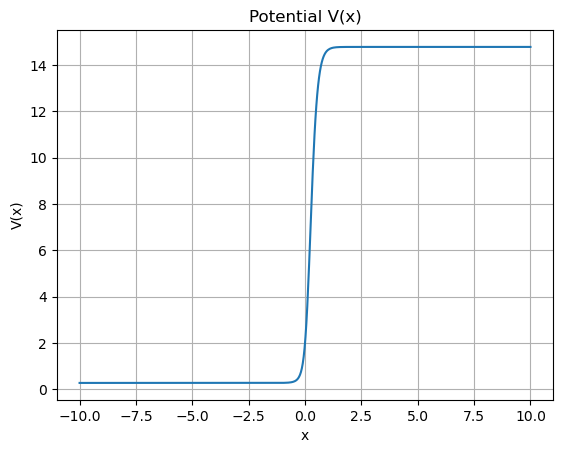

In [20]:
def PotentialVx(x,a,b,c):
    return a * np.exp(b * np.tanh(c * x))

x=np.linspace(XMIN, XMAX, 500)
Vx=PotentialVx(x,a,b,c)
plt.plot(x,Vx)
plt.title('Potential V(x)')
plt.xlabel('x')
plt.ylabel('V(x)')
plt.grid()
plt.show()

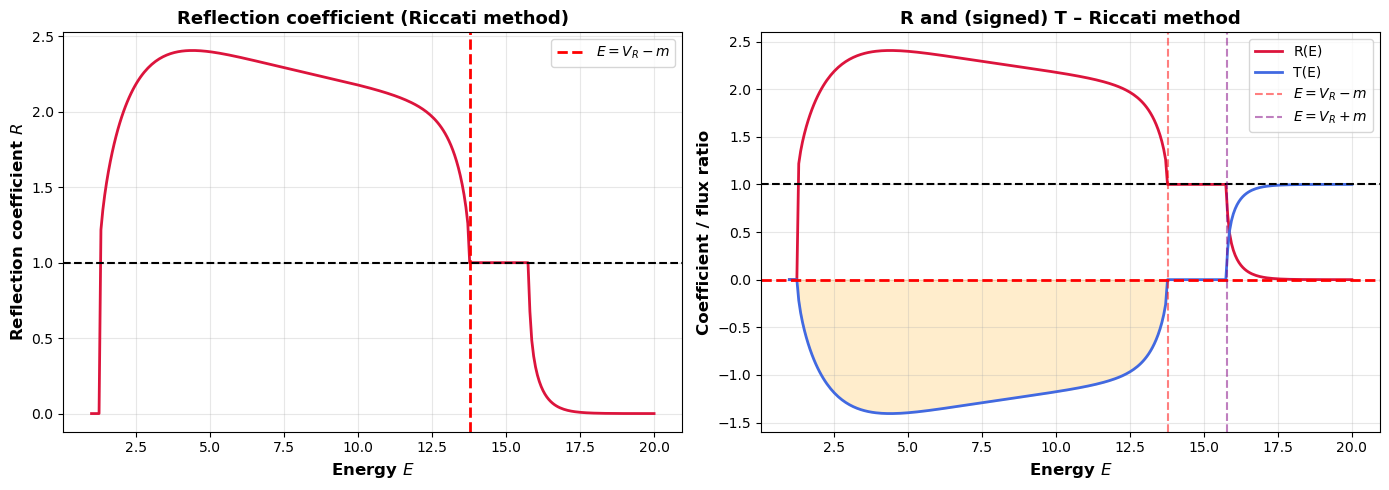

In [21]:

# Reflection only (like Fig. 2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(E_vals, R_vals, linewidth=2, color='crimson')
ax.axvline(E_sr, linestyle='--', color='red', linewidth=2, label=r'$E = V_R - m$')
ax.axhline(1.0, linestyle='--', color='black', linewidth=1.5)
ax.set_xlabel(r'Energy $E$', fontsize=12, fontweight='bold')
ax.set_ylabel(r'Reflection coefficient $R$', fontsize=12, fontweight='bold')
ax.set_title('Reflection coefficient (Riccati method)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Reflection + signed transmission (like Fig. 3)
ax = axes[1]
ax.plot(E_vals, R_vals, linewidth=2, color='crimson', label='R(E)', linestyle='-')
ax.plot(E_vals, T_vals, linewidth=2, color='royalblue', label='T(E)', linestyle='-')
ax.axhline(0.0, color='red', linewidth=2, linestyle='--')
ax.axhline(1.0, color='black', linewidth=1.5, linestyle='--')
ax.axvline(E_sr, linestyle='--', color='red', linewidth=1.5, alpha=0.5, label=r'$E = V_R - m$')
ax.axvline(E_prop, linestyle='--', color='purple', linewidth=1.5, alpha=0.5, label=r'$E = V_R + m$')
ax.fill_between(E_vals, 0, T_vals, where=(T_vals < 0), alpha=0.2, color='orange')
ax.set_xlabel(r'Energy $E$', fontsize=12, fontweight='bold')
ax.set_ylabel('Coefficient / flux ratio', fontsize=12, fontweight='bold')
ax.set_title('R and (signed) T – Riccati method', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


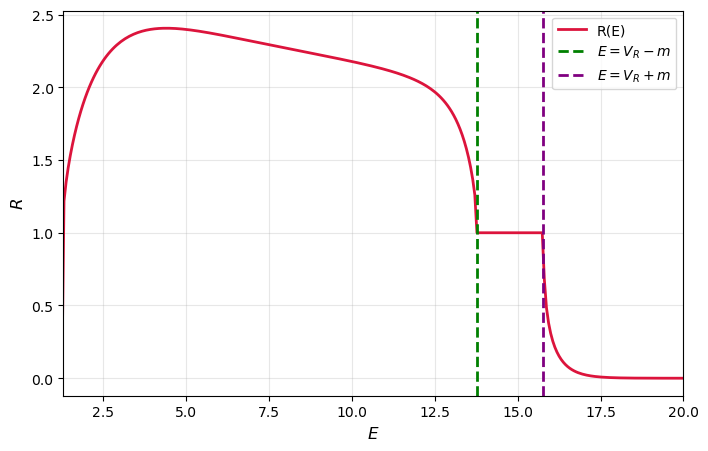

In [22]:
plt.figure(figsize=(8,5))
plt.plot(E_vals, R_vals, linewidth=2, color='crimson', label='R(E)')
#plt.plot(E_vals, T_vals, linewidth=2, color='royalblue', label='T(E)')
plt.axvline(E_sr, linestyle='--', color='green', linewidth=2, label=r'$E = V_R - m$')
plt.axvline(E_prop, linestyle='--', color='purple', linewidth=2, label=r'$E = V_R + m$')
plt.legend()
plt.xlabel(r'$E$', fontsize=12, fontweight='bold')
plt.xlim(1.3,20)
plt.ylabel(r'$R$', fontsize=12, fontweight='bold')
plt.grid(True,alpha=0.3)
plt.savefig('figures/RvE-c1.png', dpi=300)
plt.show()

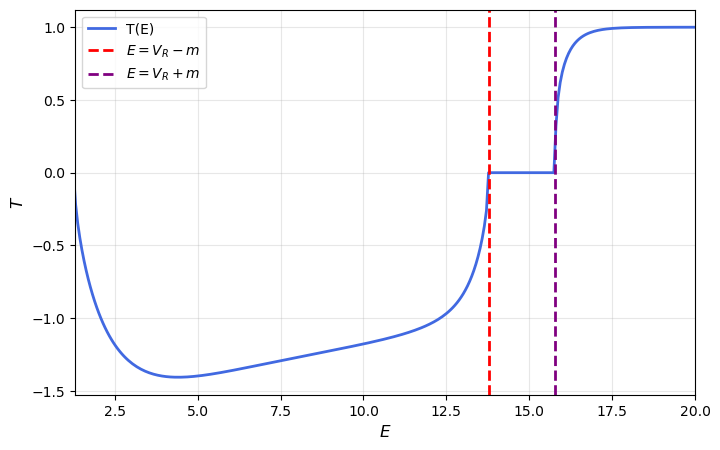

In [23]:
plt.figure(figsize=(8,5))
#plt.plot(E_vals, R_vals, linewidth=2, color='crimson', label='R(E)')
plt.plot(E_vals, T_vals, linewidth=2, color='royalblue', label='T(E)')
plt.axvline(E_sr, linestyle='--', color='red', linewidth=2, label=r'$E = V_R - m$')
plt.axvline(E_prop, linestyle='--', color='purple', linewidth=2, label=r'$E = V_R + m$')
plt.legend()
plt.xlabel(r'$E$', fontsize=12, fontweight='bold')
plt.xlim(1.3,20)
plt.ylabel(r'$T$', fontsize=12, fontweight='bold')
plt.grid(True,alpha=0.3)
plt.savefig('figures/TvE-c1.png', dpi=300)
plt.show()

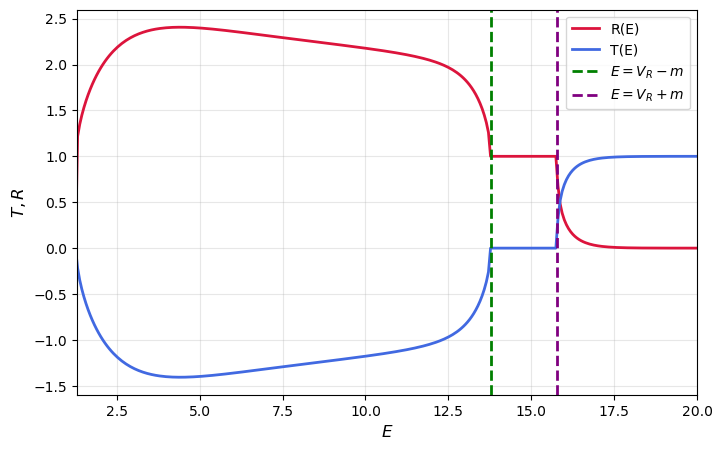

In [24]:
plt.figure(figsize=(8,5))
plt.plot(E_vals, R_vals, linewidth=2, color='crimson', label='R(E)')
plt.plot(E_vals, T_vals, linewidth=2, color='royalblue', label='T(E)')
plt.axvline(E_sr, linestyle='--', color='green', linewidth=2, label=r'$E = V_R - m$')
plt.axvline(E_prop, linestyle='--', color='purple', linewidth=2, label=r'$E = V_R + m$')
plt.legend()
plt.xlabel(r'$E$', fontsize=12, fontweight='bold')
plt.xlim(1.3,20)
plt.ylabel(r'$T, R$', fontsize=12, fontweight='bold')
plt.grid(True,alpha=0.3)
plt.savefig('figures/R-TvE-c1.png', dpi=300)
plt.show()

## CASE 2

In [25]:



# ============================================================
# Physical parameters and potential
# ============================================================

m = 1.0
a = 5.0
b = 1
c = 6

# Asymptotic potential values
VL = a * np.exp(-b)   # x -> -infinity
VR = a * np.exp(+b)   # x -> +infinity

# Thresholds
E_sr   = VR - m   # superradiance threshold
E_prop = VR + m   # propagation threshold

# Spatial box
XMIN = -10.0
XMAX =  10.0

# Integrator parameters (JIT RK4)
N_STEPS = 6000
Y_MAX = 1e6
EPS_DENOM = 1e-12


# ============================================================
# JIT versions of core functions
# ============================================================

@njit(cache=True)
def V_of_x_nb(x):
    return a * np.exp(b * np.tanh(c * x))

@njit(cache=True)
def local_k_scalar_nb(E, x):
    V = V_of_x_nb(x)
    z = (E - V)**2 - m**2
    # complex-safe sqrt using np.sqrt over complex
    return np.sqrt(z + 0j)

@njit(cache=True)
def asymptotic_k_nb(E, V_asym):
    z = (E - V_asym)**2 - m**2
    k = np.sqrt(z + 0j)
    # If nearly real, choose sign for group velocity
    if abs(k.imag) < 1e-14:
        base = abs(k.real)
        sgn = 1.0 if (E - V_asym) >= 0 else -1.0
        return sgn * base + 0j
    return k

@njit(cache=True)
def riccati_rhs_nb(x, y, E):
    k = local_k_scalar_nb(E, x)
    return -y*y - k*k

@njit(cache=True)
def integrate_riccati_nb(E, xmin, xmax, N, y_max):
    xR = xmax
    xL = xmin
    h = (xL - xR) / N  # negative step

    kR = asymptotic_k_nb(E, VR)
    y = 1j * kR

    x = xR
    for _ in range(N):
        k1 = riccati_rhs_nb(x,           y,             E)
        k2 = riccati_rhs_nb(x + 0.5*h,   y + 0.5*h*k1,  E)
        k3 = riccati_rhs_nb(x + 0.5*h,   y + 0.5*h*k2,  E)
        k4 = riccati_rhs_nb(x + h,       y + h*k3,      E)
        y += (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
        x += h
        # Cap magnitude to avoid overflow
        mag = abs(y)
        if mag > y_max:
            y = y * (y_max / mag)
    return y


# ============================================================
# Python wrappers calling JIT functions
# ============================================================

def integrate_riccati(E, xmin=XMIN, xmax=XMAX, N=N_STEPS):
    return integrate_riccati_nb(E, xmin, xmax, N, Y_MAX)


def scattering_coeffs_riccati(E, xmin=XMIN, xmax=XMAX, N=N_STEPS):
    zL = (E - VL)**2 - m**2
    if zL <= 0:
        return 0.0, 0.0

    yL = integrate_riccati(E, xmin=xmin, xmax=xmax, N=N)
    kL = asymptotic_k_nb(E, VL)

    xL = xmin
    phase_factor = np.exp(2j * kL * xL)
    denom = yL + 1j*kL
    # Regularize denominator if tiny
    if abs(denom) < EPS_DENOM:
        denom = denom + EPS_DENOM
    R_amp = phase_factor * (1j*kL - yL) / denom

    R_prob = np.abs(R_amp)**2

    zR = (E - VR)**2 - m**2
    if zR <= 0:
        return 1.0, 0.0

    T_signed = 1.0 - R_prob
    return float(R_prob), float(T_signed)


# ============================================================
# Energy scan and reporting
# ============================================================

def compute_RT_spectrum_riccati(E_min=0.0, E_max=15.0, nE=1000):
    E_vals = np.linspace(E_min, E_max, nE)
    R_vals = np.empty_like(E_vals, dtype=float)
    T_vals = np.empty_like(E_vals, dtype=float)
    for i, E in enumerate(E_vals):
        R_vals[i], T_vals[i] = scattering_coeffs_riccati(E)
    return E_vals, R_vals, T_vals


print("="*70)
print("CLEAN RICCATI METHOD - NUMBA JIT RK4")
print("="*70)



CLEAN RICCATI METHOD - NUMBA JIT RK4


In [26]:
E_vals, R_vals, T_vals = compute_RT_spectrum_riccati(
    E_min=0.0, E_max=20.0, nE=300
)

RT_sum = R_vals + T_vals
print(f"\nConservation check:")
print(f"Average R+T = {np.nanmean(RT_sum):.6f}")
print(f"Std(R+T) = {np.nanstd(RT_sum):.6f}")
print(f"Max |R+T-1| = {np.nanmax(np.abs(RT_sum - 1)):.6f}")

sr_mask = R_vals > 1.01
neg_T_mask = T_vals < -0.01

if np.any(sr_mask):
    print(f"\n✓ Found {np.sum(sr_mask)} energies with R > 1")
    print(f"  Max R = {np.nanmax(R_vals):.4f}")
if np.any(neg_T_mask):
    print(f"✓ Found {np.sum(neg_T_mask)} energies with T < 0")
    print(f"  Min T = {np.nanmin(T_vals):.4f}")

print(f"\nTheoretical superradiance window:")
print(f"  E_sr = VR - m = {E_sr:.4f}")
print(f"  E_prop = VR + m = {E_prop:.4f}")
print("="*70)


Conservation check:
Average R+T = 0.900000
Std(R+T) = 0.300000
Max |R+T-1| = 1.000000

✓ Found 146 energies with R > 1
  Max R = 3.3028
✓ Found 146 energies with T < 0
  Min T = -2.3028

Theoretical superradiance window:
  E_sr = VR - m = 12.5914
  E_prop = VR + m = 14.5914


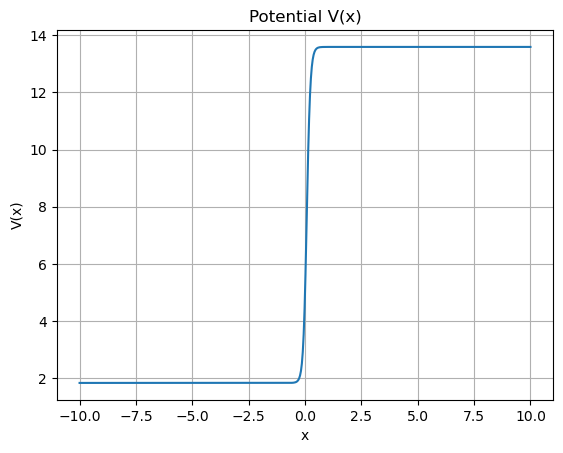

In [27]:
def PotentialVx(x,a,b,c):
    return a * np.exp(b * np.tanh(c * x))

x=np.linspace(XMIN, XMAX, 500)
Vx=PotentialVx(x,a,b,c)
plt.plot(x,Vx)
plt.title('Potential V(x)')
plt.xlabel('x')
plt.ylabel('V(x)')
plt.grid()
plt.show()

In [28]:
E_vals, R_vals, T_vals = compute_RT_spectrum_riccati(
    E_min=0.0, E_max=30.0, nE=300
)

RT_sum = R_vals + T_vals
print(f"\nConservation check:")
print(f"Average R+T = {np.nanmean(RT_sum):.6f}")
print(f"Std(R+T) = {np.nanstd(RT_sum):.6f}")
print(f"Max |R+T-1| = {np.nanmax(np.abs(RT_sum - 1)):.6f}")

sr_mask = R_vals > 1.01
neg_T_mask = T_vals < -0.01

if np.any(sr_mask):
    print(f"\n✓ Found {np.sum(sr_mask)} energies with R > 1")
    print(f"  Max R = {np.nanmax(R_vals):.4f}")
if np.any(neg_T_mask):
    print(f"✓ Found {np.sum(neg_T_mask)} energies with T < 0")
    print(f"  Min T = {np.nanmin(T_vals):.4f}")

print(f"\nTheoretical superradiance window:")
print(f"  E_sr = VR - m = {E_sr:.4f}")
print(f"  E_prop = VR + m = {E_prop:.4f}")
print("="*70)


Conservation check:
Average R+T = 0.933333
Std(R+T) = 0.249444
Max |R+T-1| = 1.000000

✓ Found 97 energies with R > 1
  Max R = 3.3027
✓ Found 97 energies with T < 0
  Min T = -2.3027

Theoretical superradiance window:
  E_sr = VR - m = 12.5914
  E_prop = VR + m = 14.5914


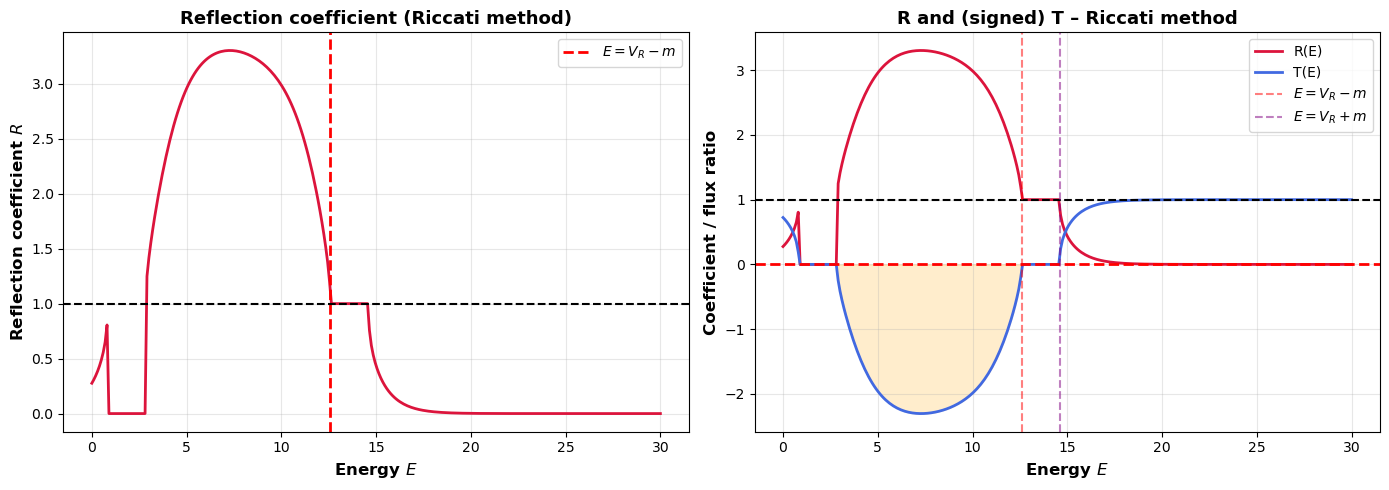

In [29]:

# Reflection only (like Fig. 2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(E_vals, R_vals, linewidth=2, color='crimson')
ax.axvline(E_sr, linestyle='--', color='red', linewidth=2, label=r'$E = V_R - m$')
ax.axhline(1.0, linestyle='--', color='black', linewidth=1.5)
ax.set_xlabel(r'Energy $E$', fontsize=12, fontweight='bold')
ax.set_ylabel(r'Reflection coefficient $R$', fontsize=12, fontweight='bold')
ax.set_title('Reflection coefficient (Riccati method)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Reflection + signed transmission (like Fig. 3)
ax = axes[1]
ax.plot(E_vals, R_vals, linewidth=2, color='crimson', label='R(E)', linestyle='-')
ax.plot(E_vals, T_vals, linewidth=2, color='royalblue', label='T(E)', linestyle='-')
ax.axhline(0.0, color='red', linewidth=2, linestyle='--')
ax.axhline(1.0, color='black', linewidth=1.5, linestyle='--')
ax.axvline(E_sr, linestyle='--', color='red', linewidth=1.5, alpha=0.5, label=r'$E = V_R - m$')
ax.axvline(E_prop, linestyle='--', color='purple', linewidth=1.5, alpha=0.5, label=r'$E = V_R + m$')
ax.fill_between(E_vals, 0, T_vals, where=(T_vals < 0), alpha=0.2, color='orange')
ax.set_xlabel(r'Energy $E$', fontsize=12, fontweight='bold')
ax.set_ylabel('Coefficient / flux ratio', fontsize=12, fontweight='bold')
ax.set_title('R and (signed) T – Riccati method', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


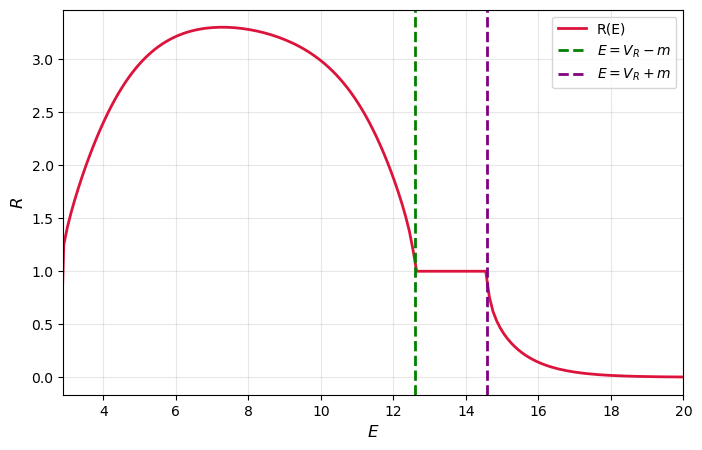

In [30]:
plt.figure(figsize=(8,5))
plt.plot(E_vals, R_vals, linewidth=2, color='crimson', label='R(E)')
#plt.plot(E_vals, T_vals, linewidth=2, color='royalblue', label='T(E)')
plt.axvline(E_sr, linestyle='--', color='green', linewidth=2, label=r'$E = V_R - m$')
plt.axvline(E_prop, linestyle='--', color='purple', linewidth=2, label=r'$E = V_R + m$')
plt.legend()
plt.xlabel(r'$E$', fontsize=12, fontweight='bold')
plt.xlim(2.9,20)
plt.ylabel(r'$R$', fontsize=12, fontweight='bold')
plt.grid(True,alpha=0.3)
plt.savefig('figures/RvE-c2.png', dpi=300)
plt.show()

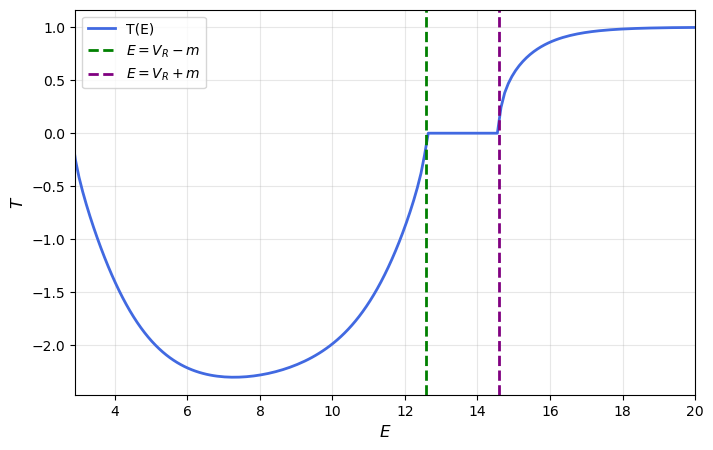

In [31]:
plt.figure(figsize=(8,5))
#plt.plot(E_vals, R_vals, linewidth=2, color='crimson', label='R(E)')
plt.plot(E_vals, T_vals, linewidth=2, color='royalblue', label='T(E)')
plt.axvline(E_sr, linestyle='--', color='green', linewidth=2, label=r'$E = V_R - m$')
plt.axvline(E_prop, linestyle='--', color='purple', linewidth=2, label=r'$E = V_R + m$')
plt.legend()
plt.xlabel(r'$E$', fontsize=12, fontweight='bold')
plt.xlim(2.9,20)
plt.ylabel(r'$T$', fontsize=12, fontweight='bold')
plt.grid(True,alpha=0.3)
plt.savefig('figures/TvE-c2.png', dpi=300)
plt.show()

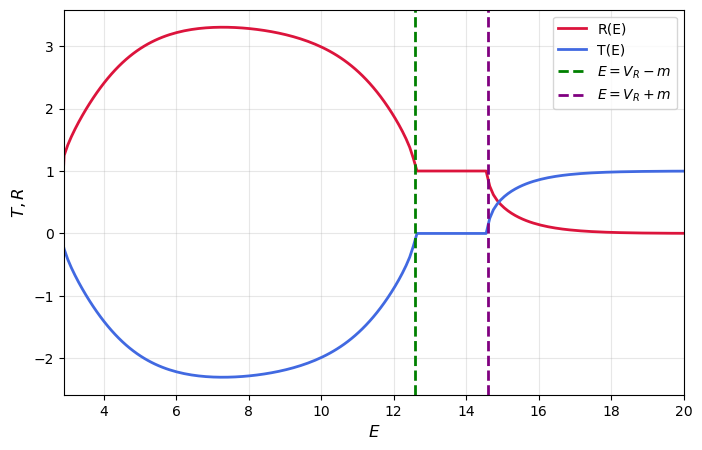

In [33]:
plt.figure(figsize=(8,5))
plt.plot(E_vals, R_vals, linewidth=2, color='crimson', label='R(E)')
plt.plot(E_vals, T_vals, linewidth=2, color='royalblue', label='T(E)')
plt.axvline(E_sr, linestyle='--', color='green', linewidth=2, label=r'$E = V_R - m$')
plt.axvline(E_prop, linestyle='--', color='purple', linewidth=2, label=r'$E = V_R + m$')
plt.legend()
plt.xlabel(r'$E$', fontsize=12, fontweight='bold')
plt.xlim(2.9,20)
plt.ylabel(r'$T, R$', fontsize=12, fontweight='bold')
plt.grid(True,alpha=0.3)
plt.savefig('figures/R-TvE-c2.png', dpi=300)
plt.show()